# **Random Forest**

Random Forest comes under Bagging Ensemble technique.

**Random Forest** is an ensemble learning method that operates by constructing a multitude of decision trees at training time. For classification tasks, the output is the class selected by the majority of the trees, while for regression tasks, it is the mean or average prediction of the individual trees.

Operates on both classification and regression problems.


### Pros and Cons of Random Forest

**Pros:**
*   **Reduced Overfitting:** By averaging multiple decision trees, it reduces the risk of overfitting compared to a single tree.
*   **High Accuracy:** Generally provides high predictive accuracy and performs well on complex datasets.
*   **Robustness:** Handles outliers and missing values effectively without requiring extensive data preprocessing.
*   **Feature Importance:** Naturally provides a ranking of which features are most important for making predictions.
*   **Versatility:** Works well for both classification and regression tasks with both categorical and continuous data.

**Cons:**
*   **Complexity:** Harder to interpret than a single decision tree; often considered a "black box" model.
*   **Computational Cost:** Training many trees can be slow and requires significant memory and CPU power for large datasets.
*   **Slow Prediction:** Real-time predictions can be slower compared to simpler models like Linear Regression or SVMs.
*   **No Extrapolation:** Like all tree-based models, it cannot predict values outside the range of the training data (for regression).



In [68]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree



import warnings
warnings.filterwarnings('ignore')

In [69]:
# making a dataset
X,y = make_classification(
    n_features=5,               # setting the number of features we want
    n_redundant=0, 
    n_informative=5,            # since we have set it to 5 and we also have 5 columns, then the number of columns which are actually useful will be set to 5 (if you reduce this value, then the number of columns which are useful will also be reduced)
    n_clusters_per_class=1      # makes different clusters based on different classification
)

df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y

print(df.shape)
df.head()


(100, 6)


,col1,col2,col3,col4,col5,target
0,0.085846,2.358865,-1.419449,2.934296,0.166979,1
1,3.811523,1.972962,0.804043,-2.557222,1.624103,0
2,0.182687,0.192393,-1.595759,-1.244279,-1.390201,0
3,-1.133179,1.015798,-1.415542,0.171921,-1.036731,1
4,-0.953329,2.507345,-3.372644,2.155251,0.732384,1


1. `n_features=5`
- Definition: The total number of columns (features) in your dataset.
- Intuition: This decides the "width" of your data. In your case, every row will have exactly 5 numbers representing the features.

2. `n_informative=5`
- Definition: The number of features that actually contain "useful" information.
- Intuition: These are the columns that have a direct mathematical relationship with the target class (0 or 1). Since you set this to 5, and your total features are 5, all of your columns are useful. There is no "garbage" data here.

3. `n_redundant=0`
- Definition: Features that are created as random linear combinations of the informative features.
- Intuition: These are "copycat" columns. They don't add new information; they just repeat what the informative columns already said in a different way. By setting this to 0, you are ensuring that every column is unique and independent.

4. `n_clusters_per_class=1`
- Definition: The number of "clusters" or groups that each class is made of.
- Intuition:
    - 1 (Your setting): All data points for Class 0 form one big island, and all points for Class 1 form another island. This makes the data easier to classify.
    - 2 or more: Class 0 might be split into two separate groups on opposite sides of the map. This makes the problem much harder for a model to solve.

In [70]:
df.shape

(100, 6)

In [ ]:
import random

# making a function for row sampling
def sample_rows(df, percent):
    return df.sample(int(percent * df.shape[0]), replace=True)


# making a function for feature sampling
def sample_feaures(df, percent):
    cols = random.sample(df.columns.tolist()[:-1], int(percent * (df.shape[1]-1)))
    new_df = df[cols]
    new_df['target'] = df['target']
    return new_df


# making a function for combined sampling
def combined_sampling(df, row_percent, col_percent):
    new_df = sample_rows(df, row_percent)
    return sample_feaures(new_df, col_percent)


In [72]:
df1 = combined_sampling(df, 0.5, 0.5)
df2 = combined_sampling(df,0.5,0.5)
df3 = combined_sampling(df,0.5,0.5)


print(df1.columns)
print(df2.columns)
print(df3.columns)

df1.head()

Index(['col3', 'col5', 'target'], dtype='object')
Index(['col5', 'col3', 'target'], dtype='object')
Index(['col2', 'col3', 'target'], dtype='object')


,col3,col5,target
63,-0.144078,-1.742859,1
80,-0.540478,-0.952704,1
5,-0.353772,0.143612,0
16,-1.201147,-0.415729,1
63,-0.144078,-1.742859,1


In [ ]:
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.5357142857142857, 0.9166666666666666, 'x[0] <= -0.445\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.35714285714285715, 0.75, 'x[1] <= 0.78\ngini = 0.245\nsamples = 21\nvalue = [3, 18]'),
 Text(0.4464285714285714, 0.8333333333333333, 'True  '),
 Text(0.21428571428571427, 0.5833333333333334, 'x[1] <= -0.959\ngini = 0.105\nsamples = 18\nvalue = [1, 17]'),
 Text(0.14285714285714285, 0.4166666666666667, 'x[1] <= -1.202\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.07142857142857142, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.21428571428571427, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.2857142857142857, 0.4166666666666667, 'gini = 0.0\nsamples = 15\nvalue = [0, 15]'),
 Text(0.5, 0.5833333333333334, 'x[1] <= 1.297\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.42857142857142855, 0.4166666666666667, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.5714285714285714, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),


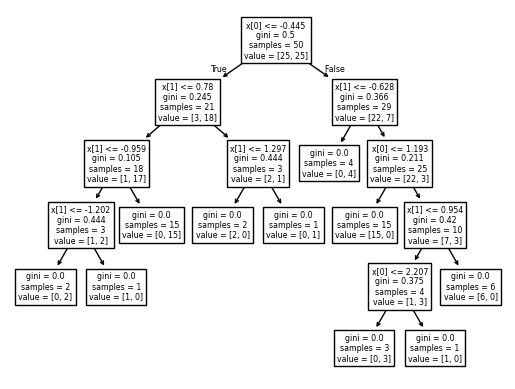

In [74]:
plot_tree(clf1)


[Text(0.4166666666666667, 0.9375, 'x[1] <= -0.864\ngini = 0.461\nsamples = 50\nvalue = [32, 18]'),
 Text(0.14285714285714285, 0.8125, 'x[1] <= -1.377\ngini = 0.43\nsamples = 16\nvalue = [5, 11]'),
 Text(0.27976190476190477, 0.875, 'True  '),
 Text(0.09523809523809523, 0.6875, 'x[1] <= -2.168\ngini = 0.494\nsamples = 9\nvalue = [5, 4]'),
 Text(0.047619047619047616, 0.5625, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.14285714285714285, 0.5625, 'x[0] <= -1.213\ngini = 0.408\nsamples = 7\nvalue = [5, 2]'),
 Text(0.09523809523809523, 0.4375, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.19047619047619047, 0.4375, 'x[0] <= -1.001\ngini = 0.48\nsamples = 5\nvalue = [3, 2]'),
 Text(0.14285714285714285, 0.3125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.23809523809523808, 0.3125, 'x[1] <= -1.908\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.19047619047619047, 0.1875, 'x[0] <= 0.51\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.14285714285714285, 0.0625, 'gini

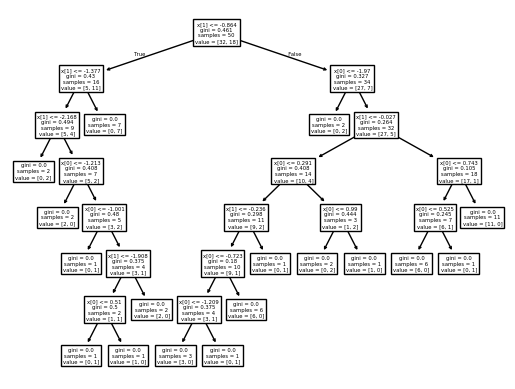

In [75]:
plot_tree(clf2)


[Text(0.6, 0.9444444444444444, 'x[1] <= -0.073\ngini = 0.493\nsamples = 50\nvalue = [22.0, 28.0]'),
 Text(0.4, 0.8333333333333334, 'x[0] <= 0.88\ngini = 0.298\nsamples = 33\nvalue = [6, 27]'),
 Text(0.5, 0.8888888888888888, 'True  '),
 Text(0.3, 0.7222222222222222, 'x[0] <= 0.321\ngini = 0.397\nsamples = 22\nvalue = [6, 16]'),
 Text(0.2, 0.6111111111111112, 'x[1] <= -1.746\ngini = 0.266\nsamples = 19\nvalue = [3, 16]'),
 Text(0.1, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.3, 0.5, 'x[1] <= -0.864\ngini = 0.198\nsamples = 18\nvalue = [2, 16]'),
 Text(0.2, 0.3888888888888889, 'gini = 0.0\nsamples = 10\nvalue = [0, 10]'),
 Text(0.4, 0.3888888888888889, 'x[1] <= -0.705\ngini = 0.375\nsamples = 8\nvalue = [2, 6]'),
 Text(0.3, 0.2777777777777778, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.5, 0.2777777777777778, 'x[1] <= -0.506\ngini = 0.245\nsamples = 7\nvalue = [1, 6]'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.6, 0.166666666

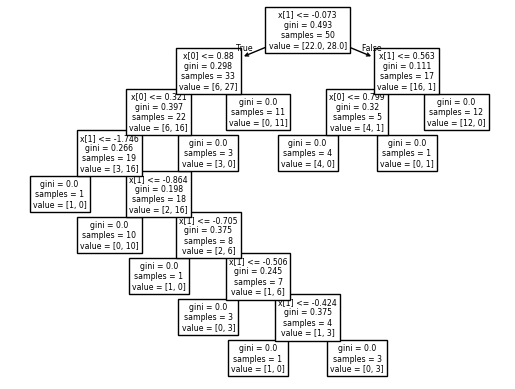

In [76]:
plot_tree(clf3)


In [86]:
print(clf1.predict(np.array([-1.042498, -0.064323]).reshape(1,2)))
print(clf2.predict(np.array([-1.042498, -0.064323]).reshape(1,2)))
print(clf3.predict(np.array([-1.042498, -0.064323]).reshape(1,2)))

df.sample(10,replace=True)

[1]
[1]
[0]


,col1,col2,col3,col4,col5,target
29,-1.466756,-0.207799,0.827767,-1.148246,-2.260453,1
12,-0.391498,-0.011166,1.417999,0.329757,1.510876,0
60,-0.395477,1.147307,0.645511,-1.121239,1.967061,0
41,-0.934051,0.768206,-0.195602,0.442378,-0.787095,1
9,2.114415,2.128218,3.524471,-1.092941,3.915386,0
60,-0.395477,1.147307,0.645511,-1.121239,1.967061,0
70,0.729325,4.648366,-4.571052,5.640668,2.625873,1
45,0.327127,4.875132,-3.221516,4.162396,-0.307278,1
86,-1.090184,0.344671,0.597963,-0.329242,-3.169344,1
36,0.013788,1.716064,-1.296813,2.106866,1.771013,1
